## **Supervised Algorithms: Validating Cluster Splittings**

## **Imports**

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## **Load and Split the Data**

In [3]:
X = pd.read_parquet('../data/processed/X_genotypes.parquet').values
y = pd.read_csv('../data/processed/y_clades_kmeans.csv').squeeze()
snp_info = pd.read_csv('../data/processed/snp_info.csv')
sample_meta_info = pd.read_csv('../data/processed/sample_meta.csv')

## **Random Forest**

### **Cluster's Classification**

In [28]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro')

/home/lucas/miniconda3/envs/clade-clustering/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [30]:
results = {}

results['Random Forest'] = {
    'mean': scores.mean(),
    'std': scores.std()
}

rf_results_df = pd.DataFrame(results)
rf_results_df

,Random Forest
mean,0.959149
std,0.081702


### **Feature Importance**

 importance       chrom     pos
   0.004047 nc_072814.1 1876910
   0.004044 nc_072818.1  597414
   0.004019 nc_072812.1 2199181
   0.003999 nc_072815.1  530451
   0.003983 nc_072814.1  333929
   0.003972 nc_072816.1  554594
   0.003946 nc_072815.1  208329
   0.003879 nc_072814.1  510975
   0.003746 nc_072816.1  165721
   0.003708 nc_072816.1   21788
   0.003686 nc_072814.1 1730746
   0.003673 nc_072815.1  284689
   0.003666 nc_072813.1 2335002
   0.003660 nc_072813.1 1632933
   0.003605 nc_072814.1  336354
   0.003563 nc_072812.1   84461
   0.003556 nc_072815.1  517699
   0.003555 nc_072812.1 3138369
   0.003529 nc_072817.1  938535
   0.003513 nc_072815.1  559764


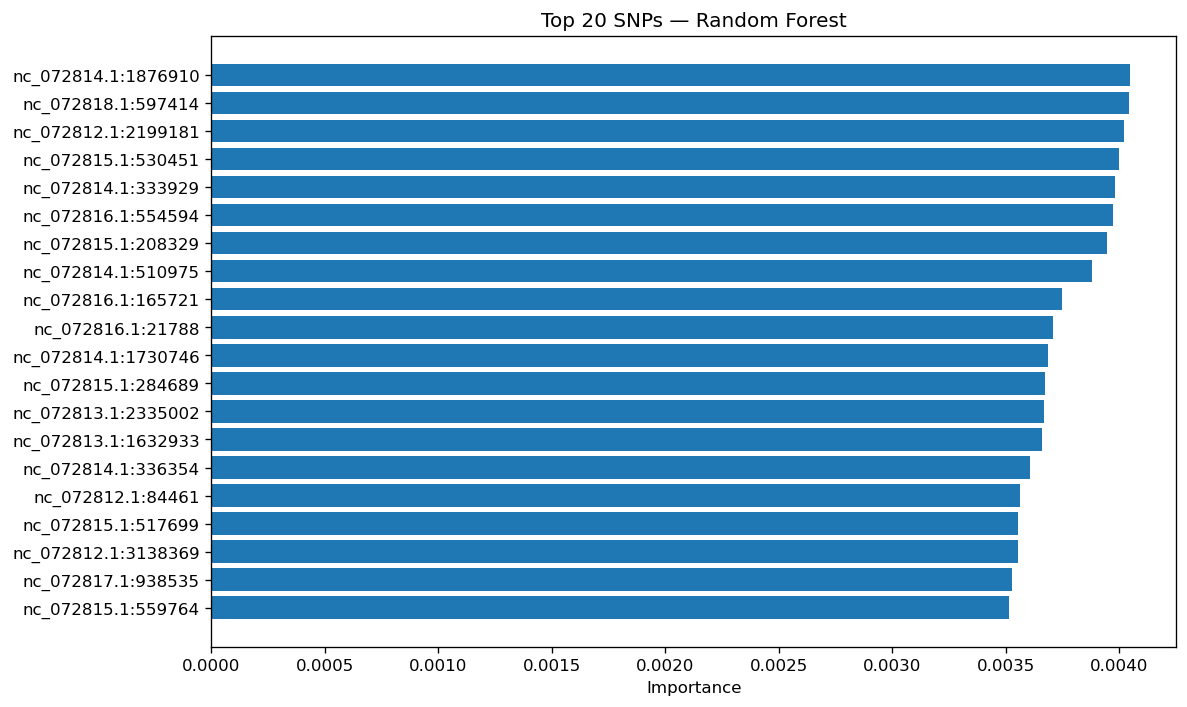

In [34]:
importances = rf.feature_importances_

fi_df = pd.DataFrame({
    'importance': importances,
    'chrom': snp_info['chrom'].values,
    'pos': snp_info['pos'].values
}).sort_values('importance', ascending=False)

top_rf = fi_df.head(20)
print(top_rf.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
labels = top_rf['chrom'] + ':' + top_rf['pos'].astype(str)
ax.barh(range(len(top_rf)), top_rf['importance'])
ax.set_yticks(range(len(top_rf)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set(xlabel='Importance', title='Top 20 SNPs — Random Forest')
fig.tight_layout()
plt.show()

In [40]:

pca = PCA(n_components=4, random_state=42)
pca.fit(X)

loadings_df = pd.DataFrame({
    'pc1_abs': np.abs(pca.components_[0]),
    'chrom': snp_info['chrom'].values,
    'pos': snp_info['pos'].values
}).sort_values('pc1_abs', ascending=False)

top_pca = set(zip(loadings_df.head(40)['chrom'], loadings_df.head(40)['pos']))
top_rf_set = set(zip(top_rf['chrom'], top_rf['pos']))

overlap = top_pca & top_rf_set
print(f'SNPs in common (top 20 PCA vs top 20 RF): {len(overlap)}')
print(overlap)

SNPs in common (top 20 PCA vs top 20 RF): 0
set()


## **LDA**

LDA components: 5
Explained variance ratio: [0.48982432 0.32316494 0.1472629  0.02887769 0.01087015]


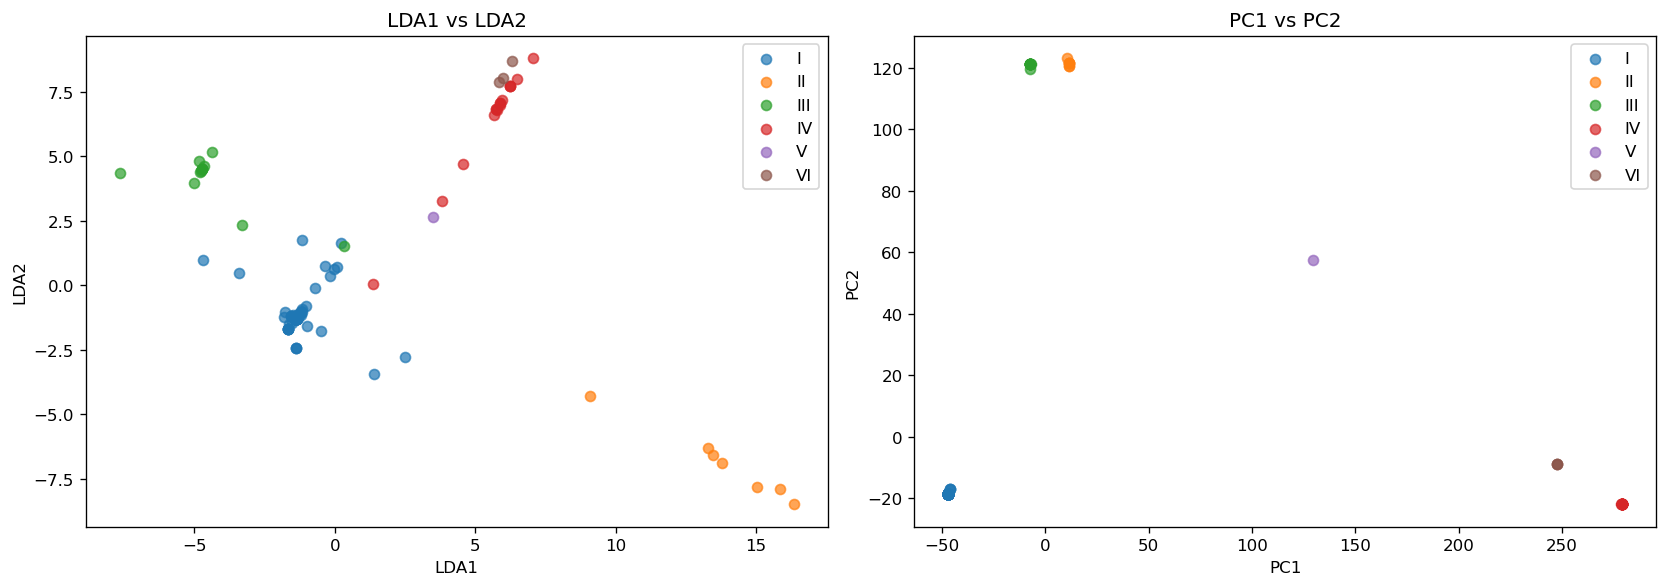

In [43]:
# --- LDA ---
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X, y)

print(f'LDA components: {X_lda.shape[1]}')  # max = n_classes - 1 = 5
print(f'Explained variance ratio: {lda.explained_variance_ratio_}')

# --- Scatter LDA1 vs LDA2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# LDA
for clade in sorted(y.unique()):
    mask = y == clade
    axes[0].scatter(X_lda[mask, 0], X_lda[mask, 1], label=clade, alpha=0.7)
axes[0].set(title='LDA1 vs LDA2', xlabel='LDA1', ylabel='LDA2')
axes[0].legend()

# PCA for comparison
from sklearn.decomposition import PCA
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X)

for clade in sorted(y.unique()):
    mask = y == clade
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=clade, alpha=0.7)
axes[1].set(title='PC1 vs PC2', xlabel='PC1', ylabel='PC2')
axes[1].legend()

fig.tight_layout()
plt.show()


In [44]:
# LDA loadings (coeficientes)
lda_coefs = pd.DataFrame({
    'lda1_abs': np.abs(lda.coef_[0]),  # coeficientes da primeira classe vs rest
    'chrom': snp_info['chrom'].values,
    'pos': snp_info['pos'].values
}).sort_values('lda1_abs', ascending=False)

top_lda = set(zip(lda_coefs.head(20)['chrom'], lda_coefs.head(20)['pos']))
top_rf_set = set(zip(fi_df.head(20)['chrom'], fi_df.head(20)['pos']))

overlap_lda_rf = top_lda & top_rf_set
print(f'SNPs in common (top 20 LDA vs top 20 RF): {len(overlap_lda_rf)}')

SNPs in common (top 20 LDA vs top 20 RF): 0
